In [2]:
#VaR tests and vizualization
from scipy.stats import *
from scipy import stats 
from typing import Union, List, Literal, TypeAlias
import numpy as np
import numpy.typing as npt
import pandas as pd
from functools import wraps, partial
from arch import arch_model
import matplotlib.pyplot as plt

from Vares_simulations import *

from Vares import _terminal_returns, historical_var

Vares.ENABLE_TIMING = False

import pickle

#import the USD data 
with open('prices_usd.pkl', 'rb') as f: 
    prices_usd = pickle.load(f)

with open('original_returns_usd.pkl', 'rb') as f: 
    original_returns_usd = pickle.load(f)

with open('log_returns_usd.pkl', 'rb') as f: 
    log_returns_usd = pickle.load(f)    

original_returns_usd_scaled = original_returns_usd * 100
log_returns_usd_scaled = log_returns_usd * 100

from GARCH_VaR_delete_or_merge import fit_GARCH_VaR, normal_GARCH_simulation

import pickle

with open("norm_vars.pkl", "rb") as f:
    _norm_vars = pickle.load(f)

def turn_var_into_real_terms(var_array, prices):
    return [np.exp(log_delta) * price for log_delta, price in zip(var_array, prices)]

In [3]:
from arch.univariate import ARX, HARX, LS, ARCHInMean #mean models 
from arch.univariate import Normal, StudentsT 
# from arch.univariate import Normal, StudentsT, SkewStudent, GeneralizedError - for now modelling these ditribututions is imposible 
from arch.univariate import GARCH, EWMAVariance, EGARCH 

from arch.univariate import ConstantMean

In [91]:
def setup(returns, lags, horizon=10, n_paths=50_000, granularity=1, alpha=0.01): 
    vol = GARCH(p=1, q=1)
    # if mean_process == 'CM' or mean_process == 'LS':
    #     model = __MEAN__[mean_process](returns)
    # if mean_process == 'harx' or mean_process == 'a-i-m' or mean_process == 'arx':
    #     model = __MEAN__[mean_process](returns, lags)
    model = ARX(returns, lags=lags)
    model.volatility = vol 
    model.distribution = Normal()
    results = model.fit(disp='off')
    h = int(horizon)                          
    forecast = results.forecast(horizon=h, method='simulation')          
    mu = results.params.get("mu", 0)
    sigma2 = forecast.variance.values[0]
    sigma = sigma2 ** (1/2) #garch model estimates the variance of the underlyinh sample

    # return forecast.mean, forecast.variance, forecast.residual_variance, results.aic
    return forecast.mean, forecast.variance
    # return results.aic, results.bic

def setup_(returns, horizon=10, n_paths=50_000, granularity=1, alpha=0.01): 
    vol = GARCH(p=1, q=1)
    # if mean_process == 'CM' or mean_process == 'LS':
    #     model = __MEAN__[mean_process](returns)
    # if mean_process == 'harx' or mean_process == 'a-i-m' or mean_process == 'arx':
    #     model = __MEAN__[mean_process](returns, lags)
    model = ConstantMean(returns)
    model.volatility = vol 
    model.distribution = Normal()
    results = model.fit(disp='off')
    h = int(horizon)                          
    # forecast = results.forecast(horizon=h, method='simulation')     
    forecast = results.forecast(horizon=h)               
    mu = results.params.get("mu", 0)
    sigma2 = forecast.variance.values[0]
    sigma = sigma2 ** (1/2) #garch model estimates the variance of the underlyinh sample

    return forecast.mean, forecast.variance, mu
    # return results.aic, results.bic

In [5]:
slice_ = log_returns_usd_scaled[600:900]
for lag in [1, 2, 3, 4, 5, 7, 10, 20, [1, 5], [1, 2, 5], [1, 5, 22], [1, 22, 60], [1, 20, 50], [1, 5, 60], [1, 5, 22, 60], 50, 100]: 
    print(lag)
    print(setup(slice_, lags=lag))
    print('---------------')

1
(         h.01      h.02      h.03      h.04      h.05      h.06      h.07  \
299 -0.048898 -0.035283 -0.032982 -0.032593 -0.032527 -0.032516 -0.032514   

         h.08      h.09      h.10  
299 -0.032514 -0.032514 -0.032514  ,          h.01      h.02      h.03      h.04      h.05      h.06     h.07  \
299  0.408812  0.439712  0.459835  0.469076  0.481601  0.500059  0.52194   

         h.08      h.09      h.10  
299  0.545164  0.555323  0.575682  )
---------------
2
(         h.01     h.02      h.03      h.04      h.05      h.06      h.07  \
299 -0.044054 -0.02805 -0.028564 -0.029285 -0.029393 -0.029384 -0.029378   

         h.08      h.09      h.10  
299 -0.029377 -0.029378 -0.029378  ,          h.01      h.02      h.03      h.04      h.05      h.06      h.07  \
299  0.421592  0.447777  0.459046  0.477471  0.493426  0.509287  0.522321   

         h.08     h.09      h.10  
299  0.550943  0.57337  0.589761  )
---------------
3
(         h.01      h.02      h.03      h.04      h.05

d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 9. The message is:
Iteration limit reached
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(


(         h.01   h.02      h.03      h.04     h.05      h.06      h.07  \
299 -0.957223  0.975 -1.569123 -2.214313 -1.05676 -2.545629  0.780403   

         h.08      h.09      h.10  
299  0.524393  0.997731 -0.767751  ,          h.01      h.02      h.03      h.04    h.05      h.06      h.07  \
299  0.000671  0.000931  0.001158  0.001398  0.0016  0.001811  0.002153   

         h.08      h.09      h.10  
299  0.002533  0.002871  0.003183  )
---------------
100
(         h.01      h.02      h.03      h.04      h.05      h.06      h.07  \
299 -3.898074 -6.724215 -1.573864  0.189972 -1.888703 -1.472319 -5.801729   

         h.08      h.09      h.10  
299 -5.336125  8.086683  3.107698  ,          h.01      h.02      h.03      h.04      h.05      h.06      h.07  \
299  0.186867  0.245703  0.306832  0.357968  0.426256  0.491212  0.550224   

         h.08     h.09     h.10  
299  0.667271  0.73812  0.82288  )
---------------


d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 9. The message is:
Iteration limit reached
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(


In [6]:
# start = 800
# slice_ = log_returns_usd_scaled[start:start+365]
# for lag in [[1, 5, 60], [1, 60], [1, 50], [1, 22], [1, 70], [1, 100], [1, 200], [1, 300], [5, 300]]: 
#     print(lag)
#     print(setup(slice_, lags=lag))
#     print('---------------')

start = 500

slice_ = log_returns_usd_scaled[start:start+365]
for lag in [1, [1, 5, 60], [1, 300]]: 
    # print(lag)    
    mean_, variance_ = setup(slice_, lags=lag)
    print(variance_.values[0])
    print(mean_.values[0])
    print('-------------------')

print(setup_(slice_)[0].values[0])
print(setup_(slice_)[1].values[0])
print(setup_(slice_)[2])



[5.80866806 5.89491426 5.96143243 6.06351168 6.07278402 6.14413329
 6.0520106  6.08401143 6.05049437 6.04950677]
[-0.10420733 -0.05269515 -0.05042585 -0.05032588 -0.05032147 -0.05032128
 -0.05032127 -0.05032127 -0.05032127 -0.05032127]
-------------------
[5.68787694 5.83503939 5.95258385 5.98396319 6.05491349 6.14099917
 6.21189083 6.23272271 6.28097868 6.31086286]
[-0.45991021 -0.51944433 -0.47672896 -0.33041652 -0.56815778 -0.26862082
 -0.22566829 -0.1960576  -0.21347451 -0.41432357]
-------------------
[5.17427639 6.17064954 6.66922194 7.13785626 7.63398436 7.92578623
 8.36640332 8.46247261 8.56995127 8.67245512]
[-0.73231574 -0.93798289 -0.71750971 -0.40137732 -0.60151811 -0.61404697
 -0.94087098 -0.70697744 -0.76569089 -0.58936582]
-------------------
[-0.05020288 -0.05020288 -0.05020288 -0.05020288 -0.05020288 -0.05020288
 -0.05020288 -0.05020288 -0.05020288 -0.05020288]
[5.92674354 6.05069555 6.03098469 6.08397229 6.12011835 6.14363977
 6.11750774 6.08182295 6.1616021  6.203307

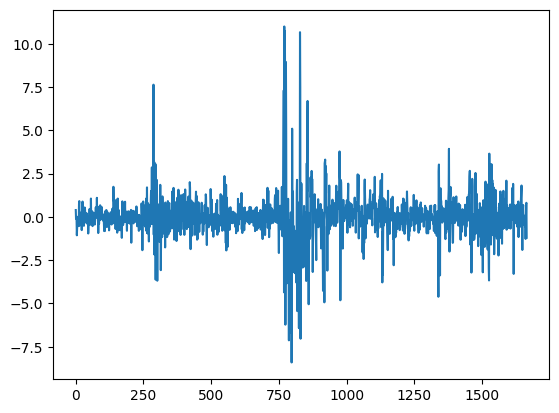

In [7]:
plt.plot(log_returns_usd_scaled)

In [20]:
def solve_local_vol_gbm_log_mean(params: GBMParams, 
        T: int,
        n_paths: int = 5000,
        S_0: float = 1,
        seed = None): 
    '''Same as solve_local_vol_gbm(), but handles log returns and allows for dynamic mean process'''

    #the limitation of the presented model is the requirement of the fitted means to be equal to volatilities in amount
    if params.volatility.shape[0] != params.mean.shape[0]:
        raise ValueError('params.volatility.shape[0] has to be equal to params.mean.shape[0]')
        
    if T < params.volatility.shape[0]: 
        raise ValueError('Quantity of forecasted volatility can not exceed number of days to simulte')
    elif T > params.volatility.shape[0]:
        print('Number of simulated days exceed number of forecasted volality points. Simulation will assume constant long-term volatility.')

    W_t = stats.norm.rvs(scale=1, size=(n_paths, T), random_state=seed)
    d_log_S = np.zeros(shape=(n_paths, T))
    #infering daily price 
    for t in range(params.volatility.shape[0]): 
        d_log_S[:, t:t+1] = (params.mean[t]
                + params.volatility[t] * W_t[:, t:t+1])
    _ = params.volatility.shape[0] 
    d_log_S[:, _:] = (params.mean[-1]
                + params.volatility[-1] * W_t[:, _:])
    
    cum_log_returns = np.sum(d_log_S, axis=-1)
    return cum_log_returns

@Auxiliary.timer
def solve_local_vol_gbm_log(
        params: GBMParams, 
        T: int,
        n_paths: int = 5000,
        S_0: float = 1,
        seed = None): 
    '''Same as solve_local_vol_gbm(), but handles log returns'''
    
    if T < params.volatility.shape[0]: 
        raise ValueError('Quantity of forecasted volatility can not exceed number of days to simulte')
    elif T > params.volatility.shape[0]:
        print('Number of simulated days exceed number of forecasted volality points. Simulation will assume constant long-term volatility.')

    W_t = stats.norm.rvs(scale=1, size=(n_paths, T), random_state=seed)
    d_log_S = np.zeros(shape=(n_paths, T))
    #infering daily price 
    for t in range(params.volatility.shape[0]): 
        d_log_S[:, t:t+1] = (params.mean 
                + params.volatility[t] * W_t[:, t:t+1])
    _ = params.volatility.shape[0] 
    d_log_S[:, _:] = (params.mean
                + params.volatility[-1] * W_t[:, _:])
    
    cum_log_returns = np.sum(d_log_S, axis=-1)
    return cum_log_returns

In [98]:
params_classic_1 = SimParams(mean=setup_(slice_)[0].values[0], volatility=setup_(slice_)[1].values[0])
params_classic_2 = SimParams(mean=setup_(slice_)[2], volatility=setup_(slice_)[1].values[0])

print(params_classic_1)
print(params_classic_2)

array1 = solve_local_vol_gbm_log_mean(params_classic_1, 10, 5000, seed=1)
array2 = solve_local_vol_gbm_log(params_classic_2, 10, 5000, seed=1)

print(np.mean(array1 - array2), np.std(array1 - array2))

SimParams(volatility=array([5.92674354, 5.94358516, 5.96042678, 5.9772684 , 5.99411002,
       6.01095163, 6.02779325, 6.04463487, 6.06147649, 6.07831811]), mean=array([-0.05020288, -0.05020288, -0.05020288, -0.05020288, -0.05020288,
       -0.05020288, -0.05020288, -0.05020288, -0.05020288, -0.05020288]))
SimParams(volatility=array([5.92674354, 5.94358516, 5.96042678, 5.9772684 , 5.99411002,
       6.01095163, 6.02779325, 6.04463487, 6.06147649, 6.07831811]), mean=np.float64(-0.05020287724990245))
0.0 0.0


In [196]:
start = 300

slice_ = log_returns_usd_scaled[start:start+365]

params_classic_3 = SimParams(mean=setup(slice_, 1)[0].values[0], volatility=setup(slice_, 1)[1].values[0])
params_classic_4 = SimParams(mean=setup(slice_, [1, 300])[0].values[0], volatility=setup(slice_, 1)[1].values[0])
print(params_classic_3)
print(params_classic_4)

array3 = solve_local_vol_gbm_log_mean(params_classic_3, 10, 5000, seed=1)
array4 = solve_local_vol_gbm_log_mean(params_classic_4, 10, 5000, seed=1)

print(array3)
print(array4)
print(array1)

print(historical_var(array3))
print(historical_var(array4))
print(historical_var(array1))


SimParams(volatility=array([0.23727446, 0.24668987, 0.25310799, 0.2592311 , 0.26645794,
       0.27317391, 0.27882102, 0.28406939, 0.28983125, 0.29597523]), mean=array([ 0.00566565, -0.00542485, -0.00568046, -0.00568635, -0.00568649,
       -0.00568649, -0.00568649, -0.00568649, -0.00568649, -0.00568649]))
SimParams(volatility=array([0.23727446, 0.2445104 , 0.25271278, 0.26021005, 0.26634892,
       0.27371976, 0.27948627, 0.28562974, 0.29508556, 0.30065756]), mean=array([-0.04473388, -0.02952211,  0.02284589, -0.00244104,  0.01145302,
        0.01511291,  0.03369787, -0.10294147,  0.01077444,  0.02589652]))
[-0.33178568 -0.49878047  0.16696546 ... -0.48178441  1.27616009
 -0.13172647]
[-0.34677582 -0.50840957  0.14905573 ... -0.5067845   1.27459257
 -0.13880051]
[ -6.38537415 -10.66118757   4.64876058 ... -10.62012149  27.93268708
  -2.72260032]
2.001735328101919
2.028513173584466
43.772336957688054


In [ ]:
# start = 800
# slice_ = log_returns_usd_scaled[start:start+365]
# for lag in [[1, 5, 60], [1, 60], [1, 50], [1, 22], [1, 70], [1, 100], [1, 200], [1, 300], [5, 300]]: 
#     print(lag)
#     print(setup(slice_, lags=lag))
#     print('---------------')

start = 500

slice_ = log_returns_usd_scaled[start:start+365]
for lag in [1, [1, 5, 60], [1, 300]]: 
    # print(lag)    
    mean_, variance_ = setup(slice_, lags=lag)
    print(variance_.values[0])
    print(mean_.values[0])
    print('-------------------')

print()
print()
print(setup_(slice_)[2])

